## 0. Cài đặt thư viện

In [ ]:
# Cài đặt TabNet
!pip install pytorch-tabnet -q
!pip install kaggle -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.9 MB/s eta 0:00:00


In [ ]:
# Import thư viện
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve
)

# TabNet
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

# Settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

print('✅ Import thư viện thành công!')
print(f'PyTorch version: {torch.__version__}')
print(f'GPU available: {torch.cuda.is_available()}')

✅ Import thư viện thành công!
PyTorch version: 2.11.0+cpu
GPU available: False


## 1. Tải & Khám sát dữ liệu ban đầu

In [ ]:
# Tải dataset từ Kaggle (chạy nếu dùng Colab)
# Cách 1: Upload file hotel_bookings.csv lên Colab trực tiếp
# Cách 2: Dùng Kaggle API
!kaggle datasets download -d jessemostipak/hotel-booking-demand
!unzip hotel-booking-demand.zip

# Đọc dữ liệu
df = pd.read_csv('hotel_bookings.csv')

print('=' * 50)
print('THÔNG TIN TỔNG QUAN VỀ DATASET')
print('=' * 50)
print(f'Số dòng:    {df.shape[0]:,}')
print(f'Số cột:     {df.shape[1]}')
print(f'\nPhân phối biến mục tiêu (is_canceled):')
print(df['is_canceled'].value_counts())
print(f'\nTỉ lệ hủy: {df["is_canceled"].mean()*100:.1f}%')

Dataset URL: https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand
License(s): Attribution 4.0 International (CC BY 4.0)
100% 1.25M/1.25M [00:00<00:00, 99.7MB/s]

Archive:  hotel-booking-demand.zip
  inflating: hotel_bookings.csv      
THÔNG TIN TỔNG QUAN VỀ DATASET
Số dòng:    119,390
Số cột:     32

Phân phối biến mục tiêu (is_canceled):
is_canceled
0    75166
1    44224
Name: count, dtype: int64

Tỉ lệ hủy: 37.0%


In [ ]:
# Xem 5 dòng đầu
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
# Thông tin kiểu dữ liệu
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
# Thống kê mô tả
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


---
## 2. Tiền xử lý dữ liệu (Preprocessing)
### 2.1 Xử lý Missing Values

In [ ]:
# Kiểm tra missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
}).sort_values('Missing Count', ascending=False)

print('Các cột có giá trị bị thiếu:')
print(missing_df[missing_df['Missing Count'] > 0])

Các cột có giá trị bị thiếu:
          Missing Count  Missing (%)
company          112593    94.306893
agent             16340    13.686238
country             488     0.408744
children              4     0.003350


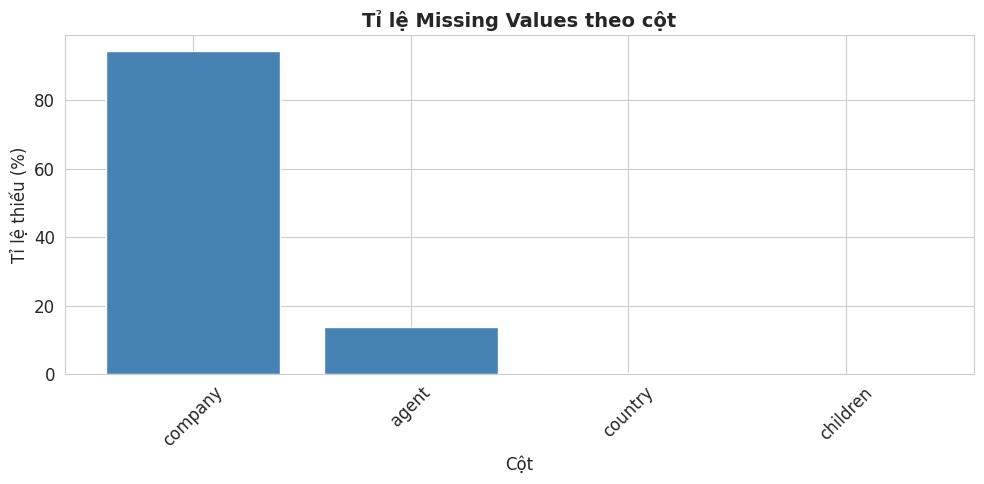

In [ ]:
# Trực quan hóa missing values
missing_cols = missing_df[missing_df['Missing Count'] > 0]

plt.figure(figsize=(10, 5))
plt.bar(missing_cols.index, missing_cols['Missing (%)'], color='steelblue', edgecolor='white')
plt.title('Tỉ lệ Missing Values theo cột', fontsize=14, fontweight='bold')
plt.xlabel('Cột')
plt.ylabel('Tỉ lệ thiếu (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Xử lý từng cột missing
df_clean = df.copy()

# 'children': thiếu rất ít → điền bằng 0 (không có trẻ em)
df_clean['children'] = df_clean['children'].fillna(0).astype(int)

# 'country': thiếu ~2% → điền bằng mode (quốc gia phổ biến nhất)
df_clean['country'] = df_clean['country'].fillna(df_clean['country'].mode()[0])

# 'agent': NaN nghĩa là khách tự đặt (không qua agent) → điền 0
df_clean['agent'] = df_clean['agent'].fillna(0).astype(int)

# 'company': NaN nghĩa là không qua công ty → điền 0
df_clean['company'] = df_clean['company'].fillna(0).astype(int)

# Kiểm tra lại
print('Sau khi xử lý missing values:')
print(f'Tổng missing còn lại: {df_clean.isnull().sum().sum()}')
print('✅ Đã xử lý xong Missing Values!')

Sau khi xử lý missing values:
Tổng missing còn lại: 0
✅ Đã xử lý xong Missing Values!


### 2.2 Xử lý Outliers

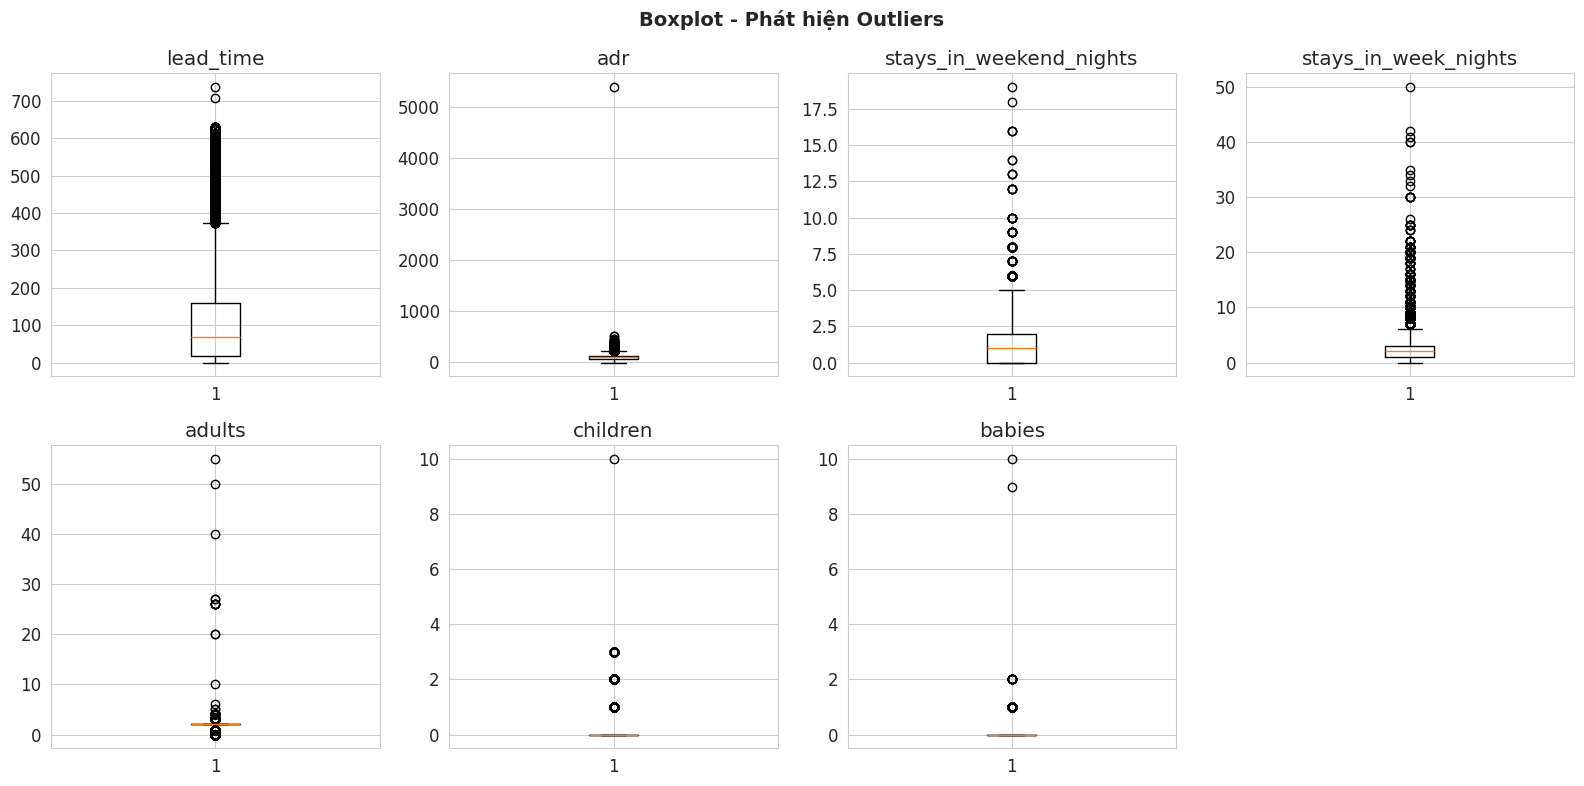

In [ ]:
# Kiểm tra outliers bằng boxplot cho các cột số quan trọng
num_cols = ['lead_time', 'adr', 'stays_in_weekend_nights',
            'stays_in_week_nights', 'adults', 'children', 'babies']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df_clean[col].dropna())
    axes[i].set_title(col)
    axes[i].set_xlabel('')

axes[-1].set_visible(False)
plt.suptitle('Boxplot - Phát hiện Outliers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Xử lý outliers bằng phương pháp IQR
def remove_outliers_iqr(df, col, factor=3.0):
    """
    Loại bỏ outliers dùng IQR với factor lớn (3.0) để chỉ xóa outliers cực đoan.
    """
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    before = len(df)
    df = df[(df[col] >= lower) & (df[col] <= upper)]
    after = len(df)
    print(f'  {col}: xóa {before - after:,} dòng outlier (còn {after:,} dòng)')
    return df

print('Xử lý outliers:')
# adr có outlier cực đoan (>5000$)
df_clean = remove_outliers_iqr(df_clean, 'adr', factor=3.0)
# lead_time: loại booking trước quá xa (>700 ngày)
df_clean = remove_outliers_iqr(df_clean, 'lead_time', factor=3.0)

# Xóa dòng không hợp lệ: adults=0, children=0, babies=0 (không có khách)
before = len(df_clean)
df_clean = df_clean[~((df_clean['adults'] == 0) &
                       (df_clean['children'] == 0) &
                       (df_clean['babies'] == 0))]
print(f'  Dòng không có khách: xóa {before - len(df_clean)} dòng')

# Xóa adr âm
before = len(df_clean)
df_clean = df_clean[df_clean['adr'] >= 0]
print(f'  adr âm: xóa {before - len(df_clean)} dòng')

print(f'\nSau xử lý outliers: {len(df_clean):,} dòng (từ {len(df):,} dòng ban đầu)')
print('✅ Đã xử lý xong Outliers!')

Xử lý outliers:
  adr: xóa 327 dòng outlier (còn 119,063 dòng)
  lead_time: xóa 164 dòng outlier (còn 118,899 dòng)
  Dòng không có khách: xóa 180 dòng
  adr âm: xóa 1 dòng

Sau xử lý outliers: 118,718 dòng (từ 119,390 dòng ban đầu)
✅ Đã xử lý xong Outliers!


### 2.3 Mã hóa dữ liệu (Encoding)

In [ ]:
# Xác định các cột categorical và numerical
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'is_canceled']

print(f'Cột categorical ({len(cat_cols)}): {cat_cols}')
print(f'\nCột numerical ({len(num_cols)}): {num_cols}')

Cột categorical (12): ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']

Cột numerical (19): ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


In [ ]:
# Label Encoding cho các cột categorical
# (TabNet xử lý tốt với Label Encoding + embedding)
df_encoded = df_clean.copy()
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
    print(f'  {col}: {len(le.classes_)} giá trị duy nhất')

print('\n✅ Đã mã hóa xong các cột categorical!')

  hotel: 2 giá trị duy nhất
  arrival_date_month: 12 giá trị duy nhất
  meal: 5 giá trị duy nhất
  country: 177 giá trị duy nhất
  market_segment: 8 giá trị duy nhất
  distribution_channel: 5 giá trị duy nhất
  reserved_room_type: 9 giá trị duy nhất
  assigned_room_type: 11 giá trị duy nhất
  deposit_type: 3 giá trị duy nhất
  customer_type: 4 giá trị duy nhất
  reservation_status: 3 giá trị duy nhất
  reservation_status_date: 926 giá trị duy nhất

✅ Đã mã hóa xong các cột categorical!


### 2.4 Chuẩn hóa dữ liệu (Scaling)

In [ ]:
# Feature Engineering: tạo thêm features hữu ích
df_encoded['total_stays'] = df_encoded['stays_in_weekend_nights'] + df_encoded['stays_in_week_nights']
df_encoded['total_guests'] = df_encoded['adults'] + df_encoded['children'] + df_encoded['babies']
df_encoded['total_cost'] = df_encoded['adr'] * df_encoded['total_stays']

print('Đã tạo thêm features:')
print('  - total_stays: tổng số đêm lưu trú')
print('  - total_guests: tổng số khách')
print('  - total_cost: tổng chi phí ước tính')

# Cập nhật danh sách num_cols
num_cols_updated = num_cols + ['total_stays', 'total_guests', 'total_cost']

# Tách X và y
feature_cols = cat_cols + num_cols_updated
feature_cols = [c for c in feature_cols if c in df_encoded.columns]

# Loại bỏ các cột gây rò rỉ dữ liệu (data leakage)
leakage_cols = ['reservation_status', 'reservation_status_date']
feature_cols = [col for col in feature_cols if col not in leakage_cols]

X = df_encoded[feature_cols].copy()
y = df_encoded['is_canceled'].values

print(f'\nCác cột bị loại bỏ do rò rỉ dữ liệu: {leakage_cols}')
print(f'Shape X: {X.shape}')
print(f'Shape y: {y.shape}')

Đã tạo thêm features:
  - total_stays: tổng số đêm lưu trú
  - total_guests: tổng số khách
  - total_cost: tổng chi phí ước tính

Các cột bị loại bỏ do rò rỉ dữ liệu: ['reservation_status', 'reservation_status_date']
Shape X: (118718, 32)
Shape y: (118718,)


In [ ]:
# StandardScaler cho các cột số
scaler = StandardScaler()
num_cols_in_X = [c for c in num_cols_updated if c in X.columns]
X[num_cols_in_X] = scaler.fit_transform(X[num_cols_in_X])

print('✅ Đã chuẩn hóa xong dữ liệu số (StandardScaler)!')
print(f'\nShape cuối cùng của X: {X.shape}')
X.head(3)

✅ Đã chuẩn hóa xong dữ liệu số (StandardScaler)!

Shape cuối cùng của X: (118718, 32)


,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_stays,total_guests,total_cost
0,1,5,0,135,3,1,2,2,0,2,2.264623,-1.631688,-0.011132,-1.685207,-0.931588,-1.316398,0.247052,-0.257834,-0.081456,-0.180355,-0.103401,-0.091605,4.363868,-0.697894,-0.199846,-0.132089,-2.173394,-0.254217,-0.721044,-1.347997,0.045877,-1.080752
2,1,5,0,59,3,1,0,2,0,2,-0.916196,-1.631688,-0.011132,-1.685207,-0.931588,-0.789464,-1.491407,-0.257834,-0.081456,-0.180355,-0.103401,-0.091605,-0.342562,-0.697894,-0.199846,-0.132089,-0.565353,-0.254217,-0.721044,-0.954456,-1.353500,-0.852899
3,1,5,0,59,2,0,0,0,0,2,-0.859226,-1.631688,-0.011132,-1.685207,-0.931588,-0.789464,-1.491407,-0.257834,-0.081456,-0.180355,-0.103401,-0.091605,-0.342562,2.140887,-0.199846,-0.132089,-0.565353,-0.254217,-0.721044,-0.954456,-1.353500,-0.852899


In [ ]:
# Tách train / validation / test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15, random_state=42, stratify=y_temp
)

print('Phân chia tập dữ liệu:')
print(f'  Train:      {X_train.shape[0]:,} dòng ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Validation: {X_val.shape[0]:,} dòng ({len(X_val)/len(X)*100:.1f}%)')
print(f'  Test:       {X_test.shape[0]:,} dòng ({len(X_test)/len(X)*100:.1f}%)')

Phân chia tập dữ liệu:
  Train:      85,773 dòng (72.2%)
  Validation: 15,137 dòng (12.8%)
  Test:       17,808 dòng (15.0%)


---
## 3. Phân tích dữ liệu khám phá (EDA)
### 3.1 Phân tích tương quan (Correlation Analysis)

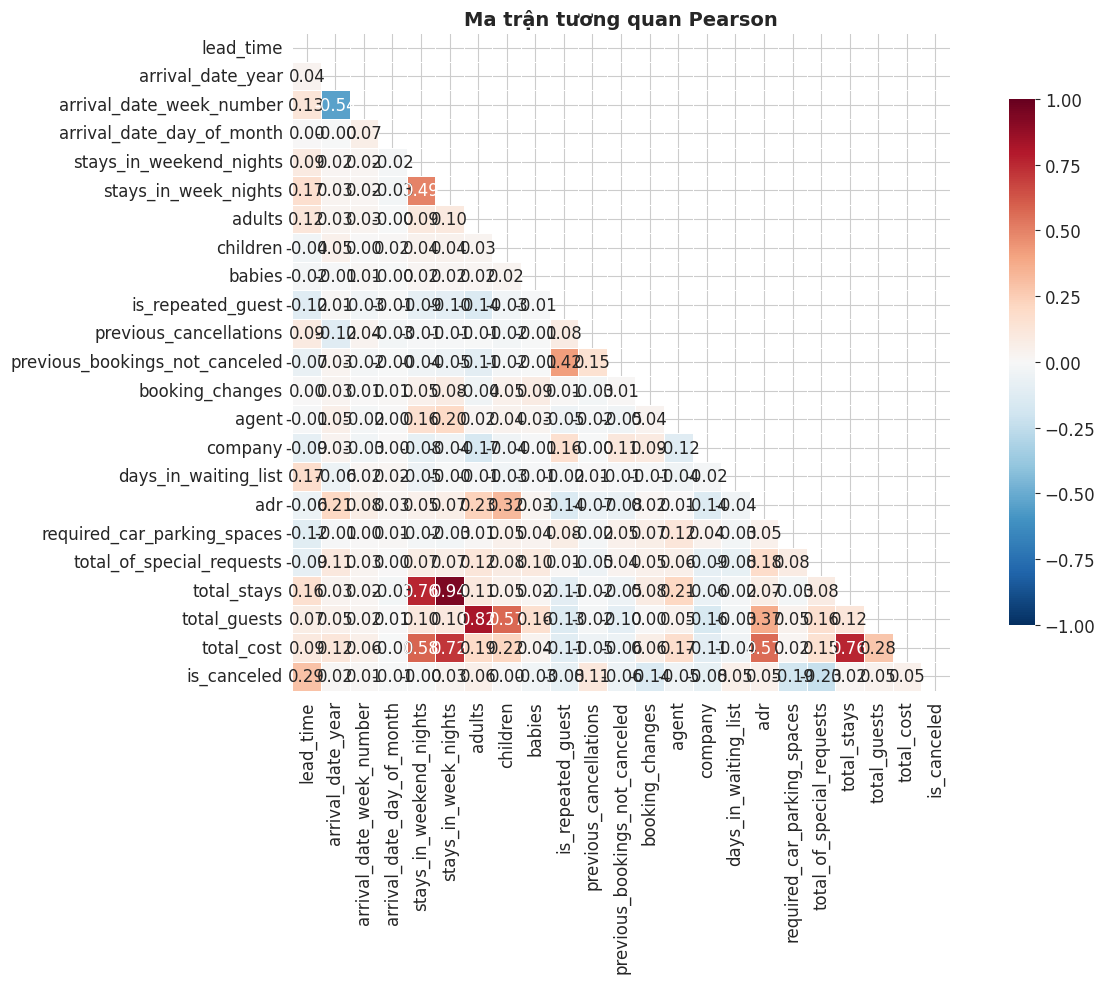

In [ ]:
# Heatmap tương quan Pearson
corr_df = df_encoded[num_cols_updated + ['is_canceled']].copy()
corr_matrix = corr_df.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Ma trận tương quan Pearson', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

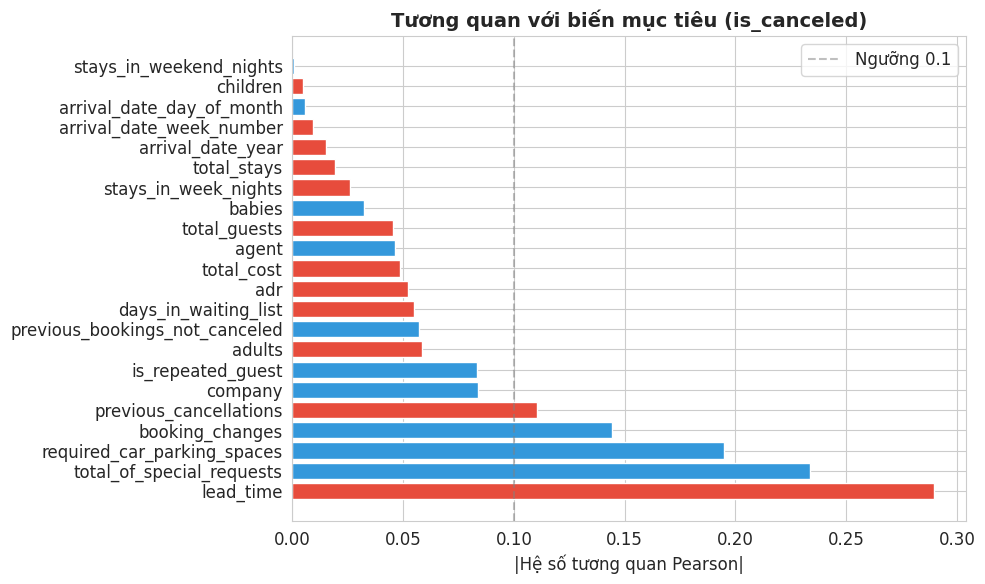

Top 10 features tương quan mạnh nhất với is_canceled:
lead_time                         0.289591
total_of_special_requests         0.233502
required_car_parking_spaces       0.194843
booking_changes                   0.144208
previous_cancellations            0.110554
company                           0.083630
is_repeated_guest                 0.083399
adults                            0.058389
previous_bookings_not_canceled    0.057310
days_in_waiting_list              0.054759
Name: is_canceled, dtype: float64


In [ ]:
# Top features tương quan với is_canceled
target_corr = corr_matrix['is_canceled'].drop('is_canceled').abs().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if v > 0 else '#3498db'
          for v in corr_matrix['is_canceled'].drop('is_canceled')[target_corr.index]]
plt.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
plt.title('Tương quan với biến mục tiêu (is_canceled)', fontsize=14, fontweight='bold')
plt.xlabel('|Hệ số tương quan Pearson|')
plt.axvline(x=0.1, color='gray', linestyle='--', alpha=0.5, label='Ngưỡng 0.1')
plt.legend()
plt.tight_layout()
plt.show()

print('Top 10 features tương quan mạnh nhất với is_canceled:')
print(target_corr.head(10))

### 3.2 Trực quan hóa (Visualization)

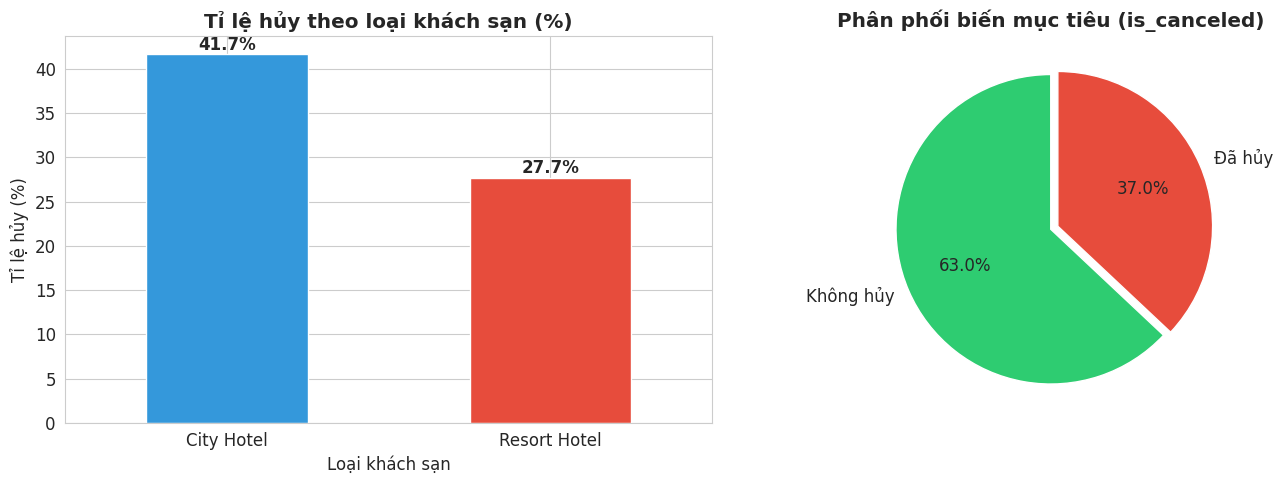

In [ ]:
# 1. Tỉ lệ hủy theo loại khách sạn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cancel_by_hotel = df_clean.groupby('hotel')['is_canceled'].mean() * 100
cancel_by_hotel.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'], edgecolor='white')
axes[0].set_title('Tỉ lệ hủy theo loại khách sạn (%)', fontweight='bold')
axes[0].set_xlabel('Loại khách sạn')
axes[0].set_ylabel('Tỉ lệ hủy (%)')
axes[0].tick_params(axis='x', rotation=0)

for bar, val in zip(axes[0].patches, cancel_by_hotel):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')

# 2. Phân phối is_canceled
cancel_counts = df_clean['is_canceled'].value_counts()
axes[1].pie(cancel_counts.values,
            labels=['Không hủy', 'Đã hủy'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%',
            startangle=90,
            explode=(0, 0.05))
axes[1].set_title('Phân phối biến mục tiêu (is_canceled)', fontweight='bold')

plt.tight_layout()
plt.show()

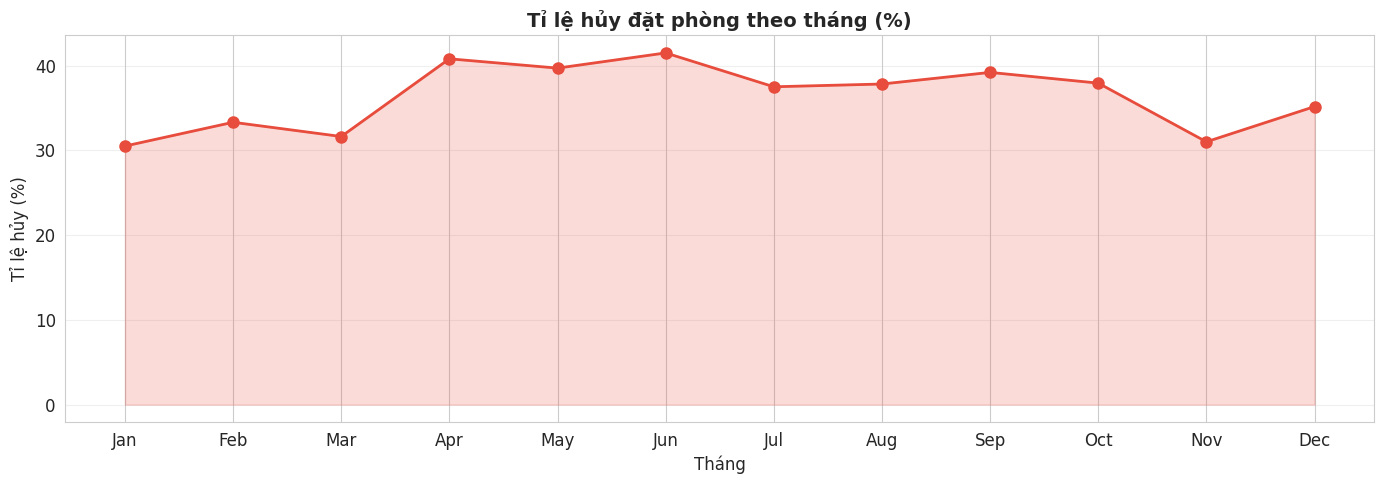

In [ ]:
# 2. Tỉ lệ hủy theo tháng
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

cancel_by_month = df_clean.groupby('arrival_date_month')['is_canceled'].mean() * 100
cancel_by_month = cancel_by_month.reindex(month_order)

plt.figure(figsize=(14, 5))
plt.plot(cancel_by_month.index, cancel_by_month.values,
         marker='o', linewidth=2, markersize=8, color='#e74c3c')
plt.fill_between(range(len(cancel_by_month)), cancel_by_month.values, alpha=0.2, color='#e74c3c')
plt.xticks(range(len(month_order)), [m[:3] for m in month_order])
plt.title('Tỉ lệ hủy đặt phòng theo tháng (%)', fontsize=14, fontweight='bold')
plt.xlabel('Tháng')
plt.ylabel('Tỉ lệ hủy (%)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

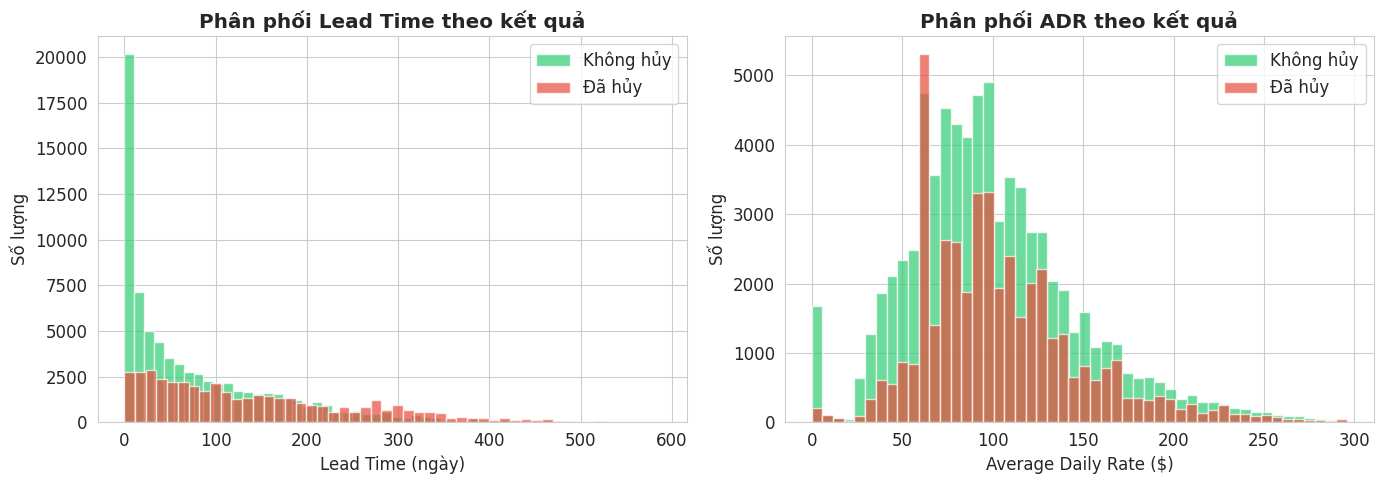

In [ ]:
# 3. Lead time vs Cancellation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of lead_time by cancellation
df_clean[df_clean['is_canceled'] == 0]['lead_time'].hist(
    ax=axes[0], bins=50, alpha=0.7, color='#2ecc71', label='Không hủy')
df_clean[df_clean['is_canceled'] == 1]['lead_time'].hist(
    ax=axes[0], bins=50, alpha=0.7, color='#e74c3c', label='Đã hủy')
axes[0].set_title('Phân phối Lead Time theo kết quả', fontweight='bold')
axes[0].set_xlabel('Lead Time (ngày)')
axes[0].set_ylabel('Số lượng')
axes[0].legend()

# ADR distribution
df_clean[df_clean['is_canceled'] == 0]['adr'].hist(
    ax=axes[1], bins=50, alpha=0.7, color='#2ecc71', label='Không hủy')
df_clean[df_clean['is_canceled'] == 1]['adr'].hist(
    ax=axes[1], bins=50, alpha=0.7, color='#e74c3c', label='Đã hủy')
axes[1].set_title('Phân phối ADR theo kết quả', fontweight='bold')
axes[1].set_xlabel('Average Daily Rate ($)')
axes[1].set_ylabel('Số lượng')
axes[1].legend()

plt.tight_layout()
plt.show()

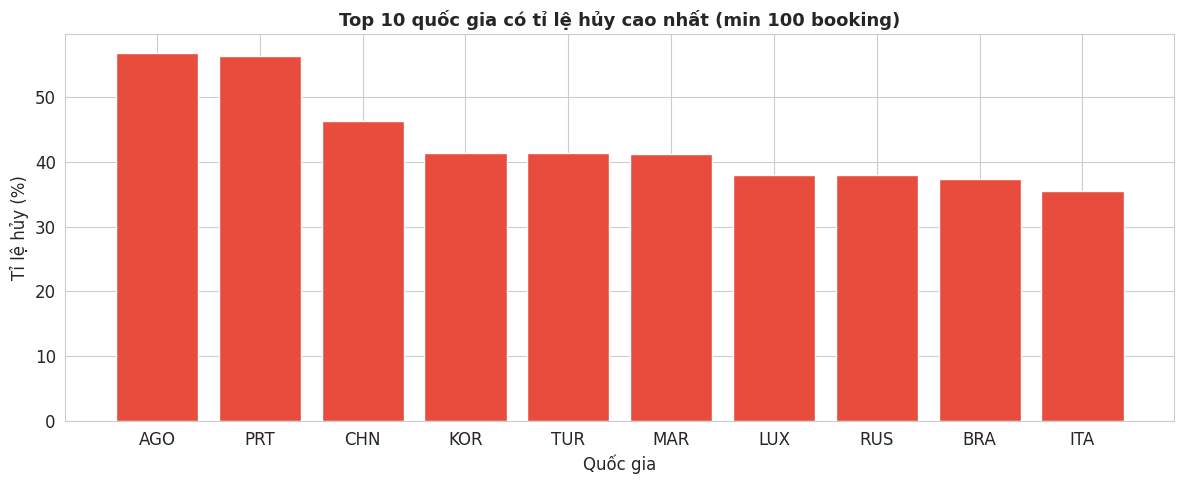

In [ ]:
# 4. Top 10 quốc gia có tỉ lệ hủy cao nhất
country_cancel = df_clean.groupby('country').agg(
    total=('is_canceled', 'count'),
    canceled=('is_canceled', 'sum')
).reset_index()
country_cancel['cancel_rate'] = country_cancel['canceled'] / country_cancel['total'] * 100
country_cancel = country_cancel[country_cancel['total'] > 100]  # chỉ lấy nước có >100 booking
top10 = country_cancel.nlargest(10, 'cancel_rate')

plt.figure(figsize=(12, 5))
plt.bar(top10['country'], top10['cancel_rate'], color='#e74c3c', edgecolor='white')
plt.title('Top 10 quốc gia có tỉ lệ hủy cao nhất (min 100 booking)', fontsize=13, fontweight='bold')
plt.xlabel('Quốc gia')
plt.ylabel('Tỉ lệ hủy (%)')
plt.tight_layout()
plt.show()

---
## 4. Huấn luyện mô hình
### 4.1 Baseline — Logistic Regression & Random Forest

In [ ]:
# Chuẩn bị dữ liệu numpy cho sklearn
X_train_np = X_train.values
X_val_np   = X_val.values
X_test_np  = X_test.values

results = {}

# --- Logistic Regression ---
print('Huấn luyện Logistic Regression...')
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_np, y_train)
lr_pred = lr.predict(X_val_np)
lr_proba = lr.predict_proba(X_val_np)[:, 1]

results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_val, lr_pred),
    'f1': f1_score(y_val, lr_pred),
    'auc': roc_auc_score(y_val, lr_proba)
}
print(f'  Accuracy: {results["Logistic Regression"]["accuracy"]:.4f}')
print(f'  F1 Score: {results["Logistic Regression"]["f1"]:.4f}')
print(f'  ROC-AUC:  {results["Logistic Regression"]["auc"]:.4f}')

Huấn luyện Logistic Regression...
  Accuracy: 0.7905
  F1 Score: 0.6711
  ROC-AUC:  0.8640


In [ ]:
# --- Random Forest ---
print('Huấn luyện Random Forest...')
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_np, y_train)
rf_pred = rf.predict(X_val_np)
rf_proba = rf.predict_proba(X_val_np)[:, 1]

results['Random Forest'] = {
    'accuracy': accuracy_score(y_val, rf_pred),
    'f1': f1_score(y_val, rf_pred),
    'auc': roc_auc_score(y_val, rf_proba)
}
print(f'  Accuracy: {results["Random Forest"]["accuracy"]:.4f}')
print(f'  F1 Score: {results["Random Forest"]["f1"]:.4f}')
print(f'  ROC-AUC:  {results["Random Forest"]["auc"]:.4f}')

Huấn luyện Random Forest...
  Accuracy: 0.8901
  F1 Score: 0.8452
  ROC-AUC:  0.9578


### 4.2 TabNet — Main Model

In [ ]:
# Chuẩn bị categorical dimensions cho TabNet
cat_cols_in_X = [c for c in cat_cols if c in X.columns]
cat_idxs = [list(X.columns).index(c) for c in cat_cols_in_X]
cat_dims = [int(df_encoded[c].nunique()) + 1 for c in cat_cols_in_X]

print(f'Số cột categorical cho TabNet: {len(cat_idxs)}')
print(f'Cat dims: {cat_dims}')

Số cột categorical cho TabNet: 10
Cat dims: [3, 13, 6, 178, 9, 6, 10, 12, 4, 5]


In [ ]:
# Định nghĩa và huấn luyện TabNet
tabnet = TabNetClassifier(
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=4,
    n_d=32,
    n_a=32,
    n_steps=5,
    gamma=1.3,
    lambda_sparse=1e-3,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-3),
    mask_type='sparsemax',
    verbose=10,
    seed=42,
    device_name='auto'
)

print('Bắt đầu huấn luyện TabNet...')
tabnet.fit(
    X_train=X_train_np, y_train=y_train,
    eval_set=[(X_val_np, y_val)],
    eval_name=['val'],
    eval_metric=['auc'],
    max_epochs=100,
    patience=15,             # Early stopping sau 15 epochs không cải thiện
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0
)
print('✅ Huấn luyện TabNet xong!')

Bắt đầu huấn luyện TabNet...
epoch 0  | loss: 0.76938 | val_auc: 0.7012  |  0:00:12s
epoch 10 | loss: 0.42363 | val_auc: 0.86753 |  0:02:10s
epoch 20 | loss: 0.36591 | val_auc: 0.90206 |  0:04:08s
epoch 30 | loss: 0.34455 | val_auc: 0.91446 |  0:06:06s
epoch 40 | loss: 0.32998 | val_auc: 0.92267 |  0:08:03s
epoch 50 | loss: 0.32209 | val_auc: 0.92506 |  0:10:02s
epoch 60 | loss: 0.31011 | val_auc: 0.93187 |  0:12:00s
epoch 70 | loss: 0.30473 | val_auc: 0.93445 |  0:13:57s
epoch 80 | loss: 0.29659 | val_auc: 0.93562 |  0:15:55s
epoch 90 | loss: 0.28994 | val_auc: 0.93862 |  0:17:53s
Stop training because you reached max_epochs = 100 with best_epoch = 98 and best_val_auc = 0.94078
✅ Huấn luyện TabNet xong!


In [ ]:
# Đánh giá TabNet trên validation set
tabnet_pred = tabnet.predict(X_val_np)
tabnet_proba = tabnet.predict_proba(X_val_np)[:, 1]

results['TabNet'] = {
    'accuracy': accuracy_score(y_val, tabnet_pred),
    'f1': f1_score(y_val, tabnet_pred),
    'auc': roc_auc_score(y_val, tabnet_proba)
}
print(f'TabNet - Validation Set:')
print(f'  Accuracy: {results["TabNet"]["accuracy"]:.4f}')
print(f'  F1 Score: {results["TabNet"]["f1"]:.4f}')
print(f'  ROC-AUC:  {results["TabNet"]["auc"]:.4f}')

TabNet - Validation Set:
  Accuracy: 0.8635
  F1 Score: 0.8075
  ROC-AUC:  0.9408


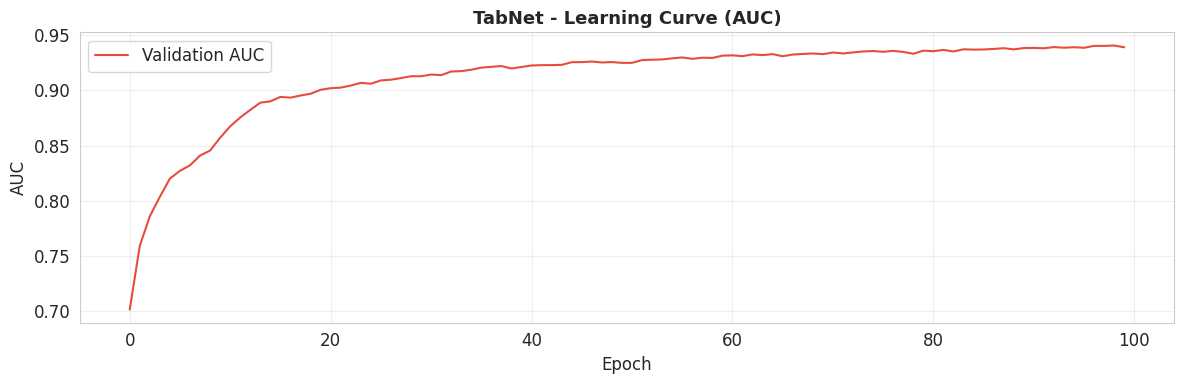

In [ ]:
# Vẽ learning curve của TabNet
plt.figure(figsize=(12, 4))
plt.plot(tabnet.history['val_auc'], label='Validation AUC', color='#e74c3c')
plt.title('TabNet - Learning Curve (AUC)', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Đánh giá & Phân tích kết quả
### 5.1 So sánh các mô hình

In [ ]:
# Bảng so sánh
results_df = pd.DataFrame(results).T.reset_index()
results_df.columns = ['Model', 'Accuracy', 'F1 Score', 'ROC-AUC']
results_df = results_df.sort_values('ROC-AUC', ascending=False)

print('So sánh các mô hình trên Validation Set:')
print(results_df.to_string(index=False))

So sánh các mô hình trên Validation Set:
              Model  Accuracy  F1 Score  ROC-AUC
      Random Forest  0.890137  0.845230 0.957770
             TabNet  0.863513  0.807492 0.940783
Logistic Regression  0.790513  0.671092 0.863957


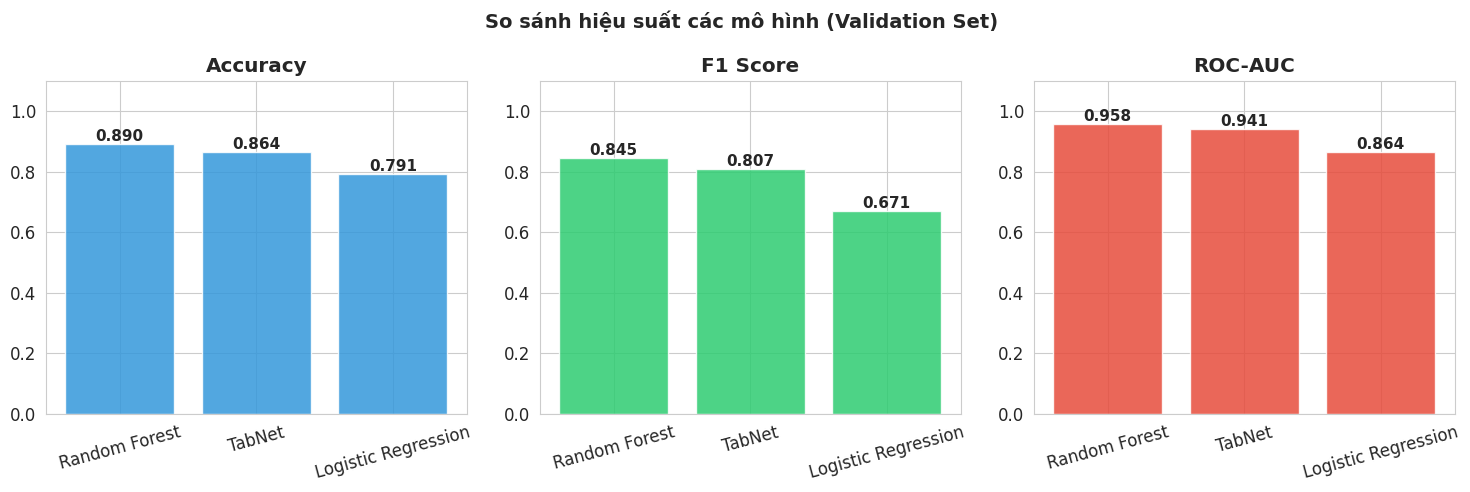

In [ ]:
# Biểu đồ so sánh
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['Accuracy', 'F1 Score', 'ROC-AUC']
colors = ['#3498db', '#2ecc71', '#e74c3c']

for ax, metric, color in zip(axes, metrics, colors):
    bars = ax.bar(results_df['Model'], results_df[metric],
                  color=color, alpha=0.85, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontweight='bold', fontsize=11)

plt.suptitle('So sánh hiệu suất các mô hình (Validation Set)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 ROC Curve

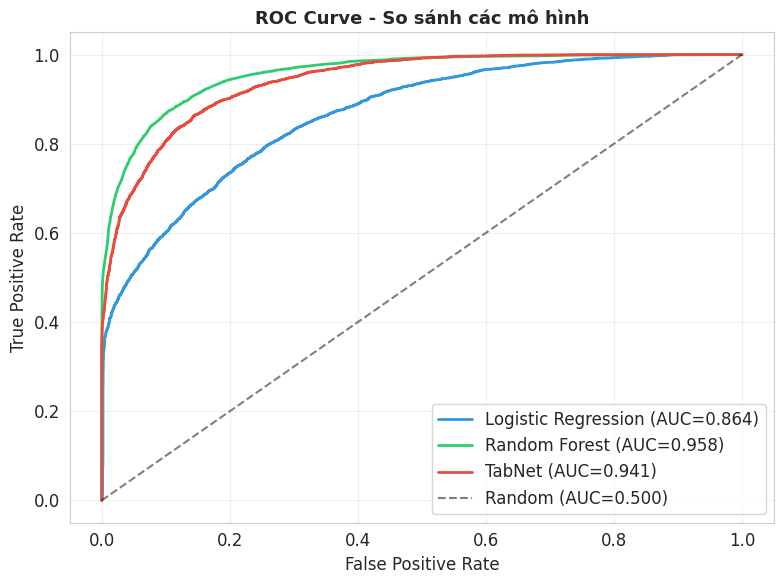

In [ ]:
# ROC Curve cho tất cả mô hình
plt.figure(figsize=(8, 6))

for (name, proba), color in zip(
    [('Logistic Regression', lr_proba),
     ('Random Forest', rf_proba),
     ('TabNet', tabnet_proba)],
    ['#3498db', '#2ecc71', '#e74c3c']
):
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc = roc_auc_score(y_val, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

plt.plot([0,1],[0,1],'k--', alpha=0.5, label='Random (AUC=0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - So sánh các mô hình', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3 Confusion Matrix

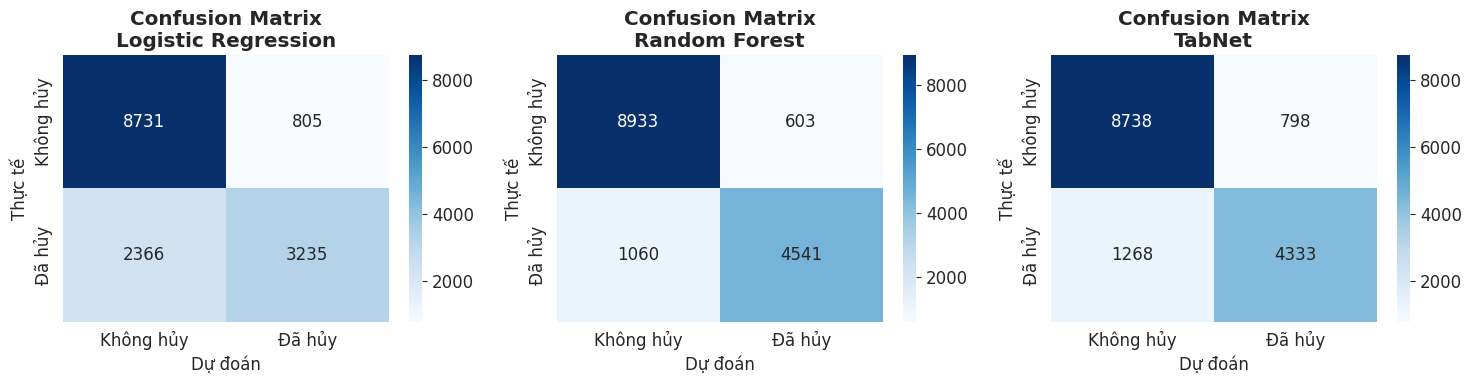

In [ ]:
# Confusion Matrix cho TabNet
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, pred) in zip(axes, [
    ('Logistic Regression', lr_pred),
    ('Random Forest', rf_pred),
    ('TabNet', tabnet_pred)
]):
    cm = confusion_matrix(y_val, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Không hủy', 'Đã hủy'],
                yticklabels=['Không hủy', 'Đã hủy'])
    ax.set_title(f'Confusion Matrix\n{name}', fontweight='bold')
    ax.set_ylabel('Thực tế')
    ax.set_xlabel('Dự đoán')

plt.tight_layout()
plt.show()

### 5.4 Feature Importance từ TabNet (Attention Mask)

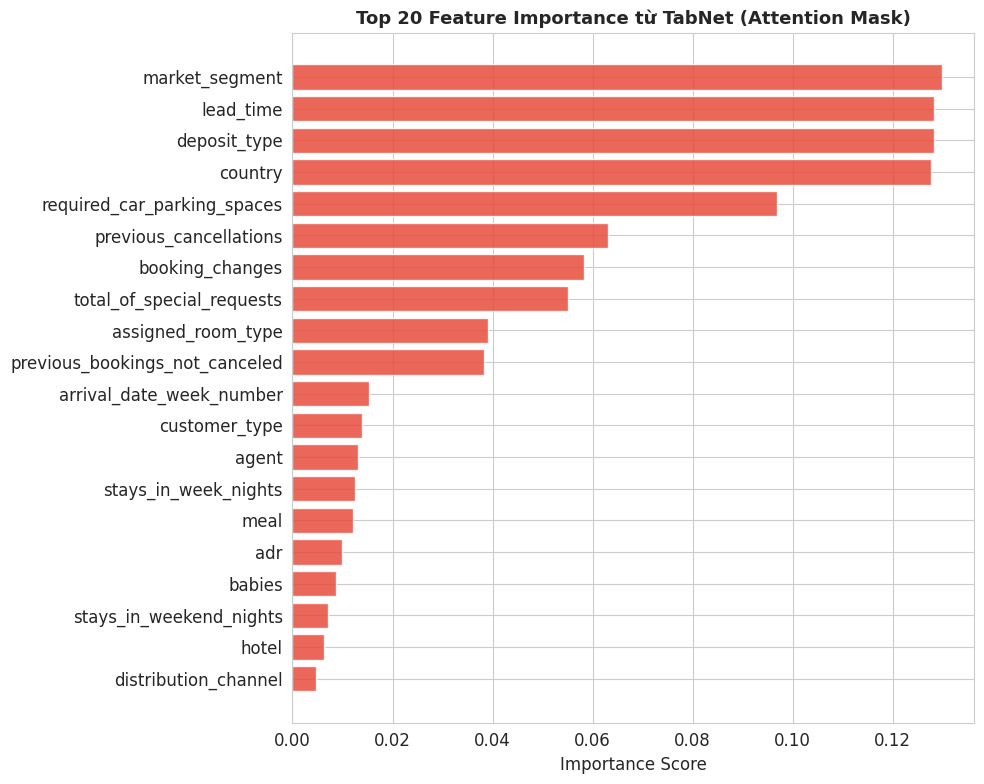

Top 10 features quan trọng nhất:
                       Feature  Importance
                market_segment    0.129756
                     lead_time    0.128342
                  deposit_type    0.128331
                       country    0.127640
   required_car_parking_spaces    0.096881
        previous_cancellations    0.063176
               booking_changes    0.058372
     total_of_special_requests    0.055059
            assigned_room_type    0.039154
previous_bookings_not_canceled    0.038209


In [ ]:
# Feature importance từ TabNet attention
feature_importances = tabnet.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': list(X.columns),
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

# Top 20 features
top_feat = feat_imp_df.head(20)

plt.figure(figsize=(10, 8))
plt.barh(top_feat['Feature'][::-1], top_feat['Importance'][::-1],
         color='#e74c3c', alpha=0.85, edgecolor='white')
plt.title('Top 20 Feature Importance từ TabNet (Attention Mask)',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 10 features quan trọng nhất:')
print(feat_imp_df.head(10).to_string(index=False))

### 5.5 Đánh giá trên Test Set (Final)

In [ ]:
# Đánh giá TabNet trên test set
test_pred = tabnet.predict(X_test_np)
test_proba = tabnet.predict_proba(X_test_np)[:, 1]

print('=' * 50)
print('KẾT QUẢ CUỐI CÙNG - TabNet trên Test Set')
print('=' * 50)
print(f'Accuracy: {accuracy_score(y_test, test_pred):.4f}')
print(f'F1 Score: {f1_score(y_test, test_pred):.4f}')
print(f'ROC-AUC:  {roc_auc_score(y_test, test_proba):.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, test_pred,
      target_names=['Không hủy', 'Đã hủy']))

KẾT QUẢ CUỐI CÙNG - TabNet trên Test Set
Accuracy: 0.8664
F1 Score: 0.8095
ROC-AUC:  0.9416

Classification Report:
              precision    recall  f1-score   support

   Không hủy       0.87      0.92      0.90     11218
      Đã hủy       0.86      0.77      0.81      6590

    accuracy                           0.87     17808
   macro avg       0.86      0.85      0.85     17808
weighted avg       0.87      0.87      0.86     17808



### 5.6 Phân tích kết quả và hướng cải thiện

In [ ]:
# Tổng kết so sánh các mô hình trên Test Set
lr_test_pred = lr.predict(X_test_np)
lr_test_proba = lr.predict_proba(X_test_np)[:, 1]
rf_test_pred = rf.predict(X_test_np)
rf_test_proba = rf.predict_proba(X_test_np)[:, 1]

final_results = {
    'Logistic Regression': {
        'Accuracy': accuracy_score(y_test, lr_test_pred),
        'F1 Score': f1_score(y_test, lr_test_pred),
        'ROC-AUC': roc_auc_score(y_test, lr_test_proba)
    },
    'Random Forest': {
        'Accuracy': accuracy_score(y_test, rf_test_pred),
        'F1 Score': f1_score(y_test, rf_test_pred),
        'ROC-AUC': roc_auc_score(y_test, rf_test_proba)
    },
    'TabNet': {
        'Accuracy': accuracy_score(y_test, test_pred),
        'F1 Score': f1_score(y_test, test_pred),
        'ROC-AUC': roc_auc_score(y_test, test_proba)
    }
}

final_df = pd.DataFrame(final_results).T
print('Kết quả cuối cùng trên TEST SET:')
print(final_df.round(4).to_string())

Kết quả cuối cùng trên TEST SET:
                     Accuracy  F1 Score  ROC-AUC
Logistic Regression    0.7987    0.6853   0.8674
Random Forest          0.8933    0.8491   0.9590
TabNet                 0.8664    0.8095   0.9416
